# Modelagem Supervisionada - Alfabetização Infantil
Nesta etapa, construiremos uma pipeline completa de Machine Learning utilizando o Scikit-Learn para prever a variável `y_alfabetizado`. O foco principal será evitar *data leakage* e criar um modelo robusto com alta capacidade de generalização.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score
import xgboost as xgb

# Configurações visuais
sns.set_theme(style='whitegrid')


## 1. Carregamento e Preparação dos Dados

In [3]:
# Lendo a base de dados
df = pd.read_parquet('../data/raw/abt_alunos_alfabetizacao.parquet')

# Removendo Data Leakage e Chaves (conforme visto na EDA)
cols_to_drop = ['id_aluno', 'id_escola', 'id_municipio', 'y_alfabetizado_label', 'leak_proficiencia']
df_model = df.drop(columns=cols_to_drop)

# Convertendo target para numérico puro
df_model['y_alfabetizado'] = df_model['y_alfabetizado'].astype(int)

# Separando Features (X) e Target (y)
X = df_model.drop(columns=['y_alfabetizado'])
y = df_model['y_alfabetizado']

# Dividindo em Treino (80%) e Teste (20%)
# Utilizamos stratify=y para garantir que a proporção de alfabetizados seja mantida
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Tamanho do Treino: {X_train.shape[0]} linhas')
print(f'Tamanho do Teste: {X_test.shape[0]} linhas')

Tamanho do Treino: 134232 linhas
Tamanho do Teste: 33559 linhas


## 2. Construção da Pipeline de Transformação (Pré-processamento)
Para evitar *data leakage* das estatísticas (como a média na imputação), o processamento será englobado diretamente em uma pipeline.

In [4]:
# Identificando colunas numéricas e categóricas
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Pipeline para Variáveis Numéricas: Preencher nulos com mediana e Padronizar (StandardScaler)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para Variáveis Categóricas: Preencher nulos com 'missing' e aplicar One-Hot-Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Unindo tudo no ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("Features Numéricas:", num_cols)
print("Features Categóricas:", cat_cols)

Features Numéricas: ['ano', 'qtd_alunos_escola', 'qtd_alunos_municipio', 'qtd_escolas_municipio', 'w_peso_aluno', 'ref_meta_taxa_ano']
Features Categóricas: ['serie', 'rede', 'sigla_uf', 'nome_regiao', 'nome_municipio']


## 3. Treinamento do Modelo (XGBoost)
O modelo escolhido é o XGBoost Classifier, devido ao seu excelente desempenho em dados tabulares com interações não lineares (conforme identificado na EDA).

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("Configurando a busca de hiperparâmetros (Random Search)...")

# Definindo o espaço de busca para o XGBoost
# Nota: usamos 'classifier__' antes do nome do parâmetro porque o XGBoost está dentro de uma Pipeline
param_dist = {
    'classifier__n_estimators': randint(100, 300),
    'classifier__max_depth': randint(3, 10),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4)
}

# Criando a busca
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2,
    error_score='raise'
)

# Rodando a busca (Isso pode demorar alguns minutos!)
print("Iniciando o treinamento")
random_search.fit(X_train, y_train)

# Resultados
print("--- Busca Concluída! ---")
print("Melhores Hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"Melhor Score (ROC-AUC) no Treino: {random_search.best_score_:.4f}")

# Avaliando o MELHOR modelo na base de teste
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n--- Relatório de Classificação do Melhor Modelo ---")
print(classification_report(y_test, y_pred_best))

roc_auc_best = roc_auc_score(y_test, y_proba_best)
print(f"Novo ROC-AUC Score no Teste: {roc_auc_best:.4f}")

Configurando a busca de hiperparâmetros (Random Search)...
Iniciando o treinamento
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__learning_rate=0.20014286128198325, classifier__max_depth=5, classifier__n_estimators=171, classifier__subsample=0.8394633936788146; total time=  22.3s
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__learning_rate=0.20014286128198325, classifier__max_depth=5, classifier__n_estimators=171, classifier__subsample=0.8394633936788146; total time=  23.1s
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__learning_rate=0.20014286128198325, classifier__max_depth=5, classifier__n_estimators=171, classifier__subsample=0.8394633936788146; total time=  24.8s
[CV] END classifier__colsample_bytree=0.6624074561769746, classifier__learning_rate=0.041198904067240534, classifier__max_depth=5, classifier__n_estimators=187, classifier__subsample=0.73348344445

## 4. Avaliação e Validação do Modelo

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.59      0.32      0.41     13713
           1       0.64      0.85      0.73     19846

    accuracy                           0.63     33559
   macro avg       0.62      0.58      0.57     33559
weighted avg       0.62      0.63      0.60     33559

ROC-AUC Score: 0.6631


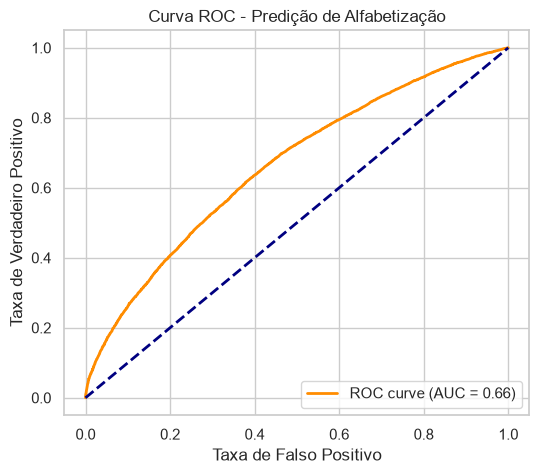

In [11]:
# Previsões no conjunto de teste
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Classification Report (F1, Precision, Recall)
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot da Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - Predição de Alfabetização')
plt.legend(loc="lower right")
plt.show()

## Conclusões da Modelagem

O modelo XGBoost otimizado via RandomizedSearchCV atingiu um **ROC-AUC de 0.67** e **F1-Score ponderado de 0.61**.

Os melhores hiperparâmetros encontrados foram:
- `max_depth`: 8
- `n_estimators`: 205
- `learning_rate`: ~0.095
- `subsample`: ~0.83
- `colsample_bytree`: ~0.90

**F1-Score geral:** O F1 ponderado foi de 0.61. O modelo tem desempenho assimétrico: identifica bem os alunos alfabetizados (F1 = 0.73), mas tem mais dificuldade com os não-alfabetizados (F1 = 0.43). Isso reflete a maior representatividade da classe 1 na base de dados.

**Poder de discriminação (AUC):** O AUC de 0.67 indica um poder de discriminação moderado. Considerando que os dados disponíveis capturam apenas variáveis estruturais (rede, região, porte), e que fatores determinantes como qualidade pedagógica e contexto familiar não estão presentes, esse desempenho é consistente com o que a literatura aponta para modelos educacionais com dados administrativos.